## 1. Project Introduction

Customer reviews are one of the most important sources of feedback for online businesses. Every review contains useful information about customer satisfaction, product quality, delivery experience, and possible issues. However, large companies receive thousands of reviews, making it difficult to manually read and understand every customer opinion.

In this project, I build a Natural Language Processing (NLP) machine learning pipeline that classifies customer reviews as positive or negative based on the text of the review. The project uses text preprocessing, TF-IDF feature engineering, multiple machine learning models, and model evaluation techniques to compare performance.

The goal of this project is not only to build a sentiment classifier, but also to understand how raw text can be transformed into useful numerical features for machine learning.

This project demonstrates skills in:

- Natural Language Processing
- Text cleaning and preprocessing
- Feature engineering using TF-IDF
- Supervised machine learning classification
- Model evaluation using accuracy, precision, recall, F1-score, confusion matrix, and ROC curve
- Error analysis
- Business-focused machine learning interpretation

## 2. Business Problem

Online businesses need a fast and reliable way to understand customer sentiment from product reviews. Manually reading thousands of reviews is time-consuming and inefficient.

A machine learning sentiment analysis model can help businesses:

- Automatically identify positive and negative customer reviews
- Detect unhappy customers faster
- Understand product quality issues
- Improve customer support response time
- Track customer satisfaction at scale

The business question for this project is:

**Can we accurately predict whether a customer review is positive or negative using only the text written by the customer?**


In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt

# Text processing
import re
import string

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

# Ignore warnings for cleaner notebook output
import warnings
warnings.filterwarnings("ignore")

## 3. Dataset Overview

The dataset contains customer reviews for Amazon products. Each row represents one customer review. The main information needed for this project is the review text and the customer rating.

The rating will be used to create a sentiment label:

- Higher ratings will be treated as positive reviews
- Lower ratings will be treated as negative reviews

Before building a machine learning model, I will inspect the dataset structure, check missing values, review important columns, and understand how the target sentiment label can be created.

In [3]:
file_path = "Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv"

df = pd.read_csv(file_path)

df.head()

,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,...,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,This product so far has not disappointed. My c...,Kindle,NaN,NaN,Adapter
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,great for beginner or experienced person. Boug...,very fast,NaN,NaN,truman
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,NaN,NaN,DaveZ
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,4.0,http://reviews.bestbuy.com/3545/5620406/review...,I've had my Fire HD 8 two weeks now and I love...,Good!!!,NaN,NaN,Shacks
4,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-12T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,NaN,NaN,explore42


In [4]:
# Check the number of rows and columns
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 34660
Number of columns: 21


In [5]:
# Display all column names
df.columns

Index(['id', 'name', 'asins', 'brand', 'categories', 'keys', 'manufacturer',
       'reviews.date', 'reviews.dateAdded', 'reviews.dateSeen',
       'reviews.didPurchase', 'reviews.doRecommend', 'reviews.id',
       'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs',
       'reviews.text', 'reviews.title', 'reviews.userCity',
       'reviews.userProvince', 'reviews.username'],
      dtype='object')

In [6]:
# Check column data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34660 entries, 0 to 34659
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    34660 non-null  object 
 1   name                  27900 non-null  object 
 2   asins                 34658 non-null  object 
 3   brand                 34660 non-null  object 
 4   categories            34660 non-null  object 
 5   keys                  34660 non-null  object 
 6   manufacturer          34660 non-null  object 
 7   reviews.date          34621 non-null  object 
 8   reviews.dateAdded     24039 non-null  object 
 9   reviews.dateSeen      34660 non-null  object 
 10  reviews.didPurchase   1 non-null      object 
 11  reviews.doRecommend   34066 non-null  object 
 12  reviews.id            1 non-null      float64
 13  reviews.numHelpful    34131 non-null  float64
 14  reviews.rating        34627 non-null  float64
 15  reviews.sourceURLs 

In [7]:
# Count missing values in each column
missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values.head(15)

reviews.userProvince    34660
reviews.userCity        34660
reviews.didPurchase     34659
reviews.id              34659
reviews.dateAdded       10621
name                     6760
reviews.doRecommend       594
reviews.numHelpful        529
reviews.date               39
reviews.rating             33
reviews.username            7
reviews.title               6
asins                       2
reviews.text                1
reviews.dateSeen            0
dtype: int64

## 4. Selecting Important Columns and Creating Sentiment Labels

For this project, I will use the review text as the input feature and the review rating to create the target label.

The original dataset includes many product-related columns, but the goal of this project is to build a text classification model. Therefore, the most important columns are:

- `reviews.text`: the written customer review
- `reviews.rating`: the numerical star rating

The star rating will be converted into a sentiment label:

- Ratings of 4 or 5 will be labeled as positive sentiment
- Ratings of 1 or 2 will be labeled as negative sentiment
- Ratings of 3 will be removed because they are neutral or unclear

Removing neutral reviews helps create a cleaner binary classification problem.

In [8]:
# Select only the columns needed for sentiment analysis
sentiment_df = df[["reviews.text", "reviews.rating"]].copy()

# Rename columns for cleaner code
sentiment_df.columns = ["review_text", "rating"]

# Display the first few rows
sentiment_df.head()

,review_text,rating
0,This product so far has not disappointed. My c...,5.0
1,great for beginner or experienced person. Boug...,5.0
2,Inexpensive tablet for him to use and learn on...,5.0
3,I've had my Fire HD 8 two weeks now and I love...,4.0
4,I bought this for my grand daughter when she c...,5.0


In [9]:
# Check missing values in the selected columns
sentiment_df.isnull().sum()

review_text     1
rating         33
dtype: int64

In [10]:
# Remove rows with missing review text or rating
sentiment_df = sentiment_df.dropna(subset=["review_text", "rating"])

# Check the shape after removing missing values
print(f"Rows after removing missing values: {sentiment_df.shape[0]}")
print(f"Columns: {sentiment_df.shape[1]}")

Rows after removing missing values: 34626
Columns: 2


In [11]:
# Check rating distribution
sentiment_df["rating"].value_counts().sort_index()

rating
1.0      410
2.0      402
3.0     1499
4.0     8541
5.0    23774
Name: count, dtype: int64

In [12]:
# Create sentiment labels from ratings
def create_sentiment_label(rating):
    if rating >= 4:
        return "positive"
    elif rating <= 2:
        return "negative"
    else:
        return "neutral"

sentiment_df["sentiment"] = sentiment_df["rating"].apply(create_sentiment_label)

# Display sentiment counts
sentiment_df["sentiment"].value_counts()

sentiment
positive    32315
neutral      1499
negative      812
Name: count, dtype: int64

In [13]:
# Remove neutral reviews for binary classification
sentiment_df = sentiment_df[sentiment_df["sentiment"] != "neutral"].copy()

# Display updated sentiment distribution
sentiment_df["sentiment"].value_counts()

sentiment
positive    32315
negative      812
Name: count, dtype: int64

In [14]:
# Convert sentiment labels into numbers for machine learning
sentiment_df["sentiment_label"] = sentiment_df["sentiment"].map({
    "negative": 0,
    "positive": 1
})

# Display final dataset preview
sentiment_df.head()

,review_text,rating,sentiment,sentiment_label
0,This product so far has not disappointed. My c...,5.0,positive,1
1,great for beginner or experienced person. Boug...,5.0,positive,1
2,Inexpensive tablet for him to use and learn on...,5.0,positive,1
3,I've had my Fire HD 8 two weeks now and I love...,4.0,positive,1
4,I bought this for my grand daughter when she c...,5.0,positive,1


## 5. Exploratory Data Analysis

Before preprocessing and modeling, I will explore the sentiment distribution and review text characteristics.

This step helps answer important questions:

- Is the dataset balanced between positive and negative reviews?
- How are customer ratings distributed?
- How long are the reviews?
- Do positive and negative reviews have different text length patterns?

Understanding these patterns is important because class imbalance and review length can affect model performance.

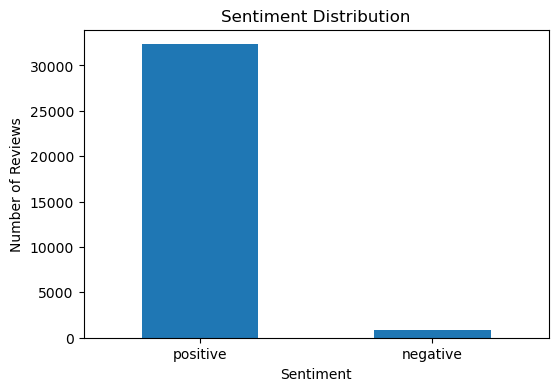

sentiment
positive    32315
negative      812
Name: count, dtype: int64

In [15]:
# Plot sentiment distribution
sentiment_counts = sentiment_df["sentiment"].value_counts()

plt.figure(figsize=(6, 4))
sentiment_counts.plot(kind="bar")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

sentiment_counts

The sentiment distribution shows that the dataset is highly imbalanced, with significantly more positive reviews than negative reviews. This is common in customer review datasets because satisfied customers often leave high ratings, and many product datasets contain mostly 4-star and 5-star reviews.

This imbalance is important because a machine learning model could achieve high accuracy by mostly predicting the majority class. Therefore, evaluation metrics such as precision, recall, F1-score, and the confusion matrix will be especially important.

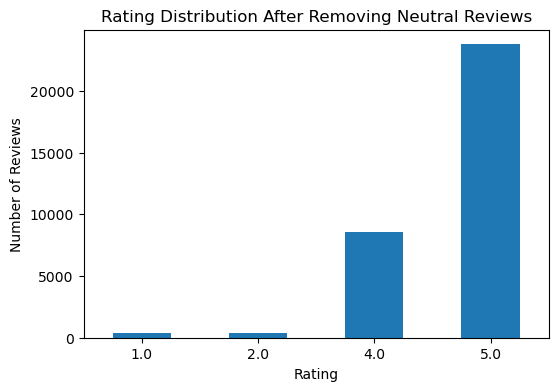

rating
1.0      410
2.0      402
4.0     8541
5.0    23774
Name: count, dtype: int64

In [16]:
# Plot original rating distribution
rating_counts = sentiment_df["rating"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
rating_counts.plot(kind="bar")
plt.title("Rating Distribution After Removing Neutral Reviews")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

rating_counts

In [17]:
# Create review length feature based on word count
sentiment_df["review_word_count"] = sentiment_df["review_text"].apply(lambda x: len(str(x).split()))

# Display summary statistics for review length
sentiment_df["review_word_count"].describe()

count    33127.000000
mean        29.860688
std         33.673217
min          1.000000
25%         13.000000
50%         20.000000
75%         35.000000
max       1858.000000
Name: review_word_count, dtype: float64

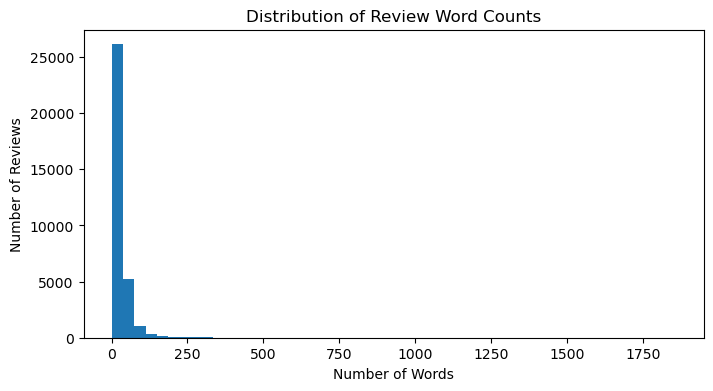

In [18]:
# Plot review word count distribution
plt.figure(figsize=(8, 4))
plt.hist(sentiment_df["review_word_count"], bins=50)
plt.title("Distribution of Review Word Counts")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.show()

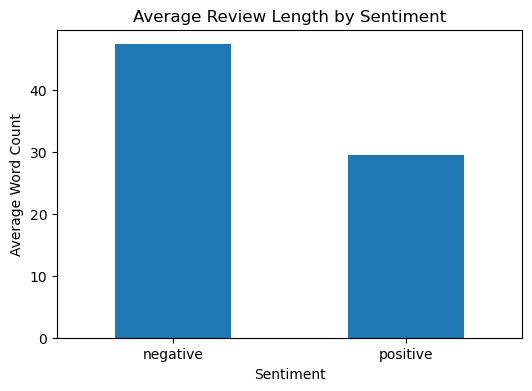

sentiment
negative    47.301724
positive    29.422435
Name: review_word_count, dtype: float64

In [19]:
# Compare average review length by sentiment
avg_length_by_sentiment = sentiment_df.groupby("sentiment")["review_word_count"].mean()

plt.figure(figsize=(6, 4))
avg_length_by_sentiment.plot(kind="bar")
plt.title("Average Review Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Word Count")
plt.xticks(rotation=0)
plt.show()

avg_length_by_sentiment

## 6. Text Cleaning and Preprocessing

Text data is unstructured, which means it cannot be used directly by most machine learning models. Before converting text into numerical features, the review text needs to be cleaned.

The preprocessing steps used in this project include:

- Lowercasing text
- Removing punctuation
- Removing numbers
- Tokenizing text into words
- Removing stopwords
- Lemmatizing words

Each step helps reduce noise and makes the text more consistent for machine learning.

In [20]:
import nltk

nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/muhammadullah/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/muhammadullah/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/muhammadullah/nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/muhammadullah/nltk_data...


True

In [21]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

In [22]:
# Create stopword set and lemmatizer
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

### Why Each Text Cleaning Step Matters

**Lowercasing:**  
Converts all words to the same format. For example, `Great`, `great`, and `GREAT` should be treated as the same word.

**Punctuation removal:**  
Removes symbols like commas, periods, and exclamation marks so the model focuses on words.

**Number removal:**  
Numbers may appear in reviews, but for this basic sentiment model, most numbers do not add strong sentiment meaning.

**Tokenization:**  
Splits a sentence into individual words. For example, `"this product is great"` becomes `["this", "product", "is", "great"]`.

**Stopword removal:**  
Removes very common words such as `the`, `is`, and `and`, which usually do not carry strong sentiment.

**Lemmatization:**  
Reduces words to their base form. For example, `running` becomes `run`, and `better` can be treated closer to its root meaning. This helps reduce duplicate word forms.

In [28]:
def clean_review_text(text):
    """
    Clean and preprocess customer review text.

    Steps:
    1. Convert text to lowercase
    2. Remove punctuation and numbers
    3. Split text into words
    4. Remove stopwords
    5. Lemmatize words
    6. Join words back into a cleaned sentence
    """

    # Convert to string and lowercase
    text = str(text).lower()

    # Remove punctuation and numbers
    text = re.sub(r"[^a-z\s]", " ", text)

    # Split text into words
    tokens = text.split()

    # Remove stopwords and lemmatize words
    cleaned_tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 2
    ]

    # Join cleaned words back into one string
    return " ".join(cleaned_tokens)

In [29]:
sample_review = sentiment_df["review_text"].iloc[0]

print("Original Review:")
print(sample_review)

print("\nCleaned Review:")
print(clean_review_text(sample_review))

Original Review:
This product so far has not disappointed. My children love to use it and I like the ability to monitor control what content they see with ease.

Cleaned Review:
product far disappointed child love use like ability monitor control content see ease


In [30]:
# Apply text cleaning to all reviews
sentiment_df["cleaned_review_text"] = sentiment_df["review_text"].apply(clean_review_text)

# Display original and cleaned text
sentiment_df[["review_text", "cleaned_review_text", "sentiment"]].head()

,review_text,cleaned_review_text,sentiment
0,This product so far has not disappointed. My c...,product far disappointed child love use like a...,positive
1,great for beginner or experienced person. Boug...,great beginner experienced person bought gift ...,positive
2,Inexpensive tablet for him to use and learn on...,inexpensive tablet use learn step nabi thrille...,positive
3,I've had my Fire HD 8 two weeks now and I love...,fire two week love tablet great value prime me...,positive
4,I bought this for my grand daughter when she c...,bought grand daughter come visit set user ente...,positive


In [31]:
# Check if any cleaned reviews are empty
empty_reviews = sentiment_df[sentiment_df["cleaned_review_text"].str.strip() == ""]

print(f"Number of empty cleaned reviews: {empty_reviews.shape[0]}")

Number of empty cleaned reviews: 3


In [32]:
# Remove rows where cleaned review text is empty
sentiment_df = sentiment_df[sentiment_df["cleaned_review_text"].str.strip() != ""].copy()

print(f"Final number of reviews after text cleaning: {sentiment_df.shape[0]}")

Final number of reviews after text cleaning: 33124


## 7. Feature Engineering Using TF-IDF

Machine learning models cannot directly understand raw text. The cleaned review text must be converted into numerical features before training a model.

In this project, I use TF-IDF vectorization.

TF-IDF stands for Term Frequency-Inverse Document Frequency. It measures how important a word is in a document compared to the entire dataset.

A word receives a higher TF-IDF score if:

- It appears often in one review
- It does not appear too frequently across all reviews

This helps the model focus on words that are more useful for classification.

In [33]:
# Define features and target
X = sentiment_df["cleaned_review_text"]
y = sentiment_df["sentiment_label"]

print("Feature sample:")
print(X.head())

print("\nTarget sample:")
print(y.head())

Feature sample:
0    product far disappointed child love use like a...
1    great beginner experienced person bought gift ...
2    inexpensive tablet use learn step nabi thrille...
3    fire two week love tablet great value prime me...
4    bought grand daughter come visit set user ente...
Name: cleaned_review_text, dtype: object

Target sample:
0    1
1    1
2    1
3    1
4    1
Name: sentiment_label, dtype: int64


In [34]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 26499
Testing samples: 6625


In [35]:
# Create TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

# Fit on training data and transform both training and testing data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"Training TF-IDF shape: {X_train_tfidf.shape}")
print(f"Testing TF-IDF shape: {X_test_tfidf.shape}")

Training TF-IDF shape: (26499, 5000)
Testing TF-IDF shape: (6625, 5000)


In [36]:
# View sample TF-IDF feature names
feature_names = tfidf_vectorizer.get_feature_names_out()

feature_names[:30]


array(['abc', 'ability', 'ability add', 'ability read', 'able',
       'able access', 'able add', 'able ask', 'able control',
       'able download', 'able find', 'able get', 'able play', 'able read',
       'able set', 'able stream', 'able take', 'able tell', 'able use',
       'able watch', 'absolute', 'absolutely', 'absolutely love',
       'absolutely loved', 'acceptable', 'access', 'access amazon',
       'access apps', 'access book', 'access google'], dtype=object)

## 8. Model Building

After converting the cleaned review text into TF-IDF features, I will train multiple supervised machine learning models and compare their performance.

The models used in this project are:

- Logistic Regression
- Multinomial Naive Bayes
- Random Forest Classifier

Using multiple models helps determine which algorithm works best for this sentiment classification problem.

In [37]:
# Initialize models
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

In [38]:
# Train each model and store predictions
model_predictions = {}

for model_name, model in models.items():
    print(f"Training {model_name}...")
    
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    
    model_predictions[model_name] = y_pred
    
    print(f"{model_name} training complete.")

Training Logistic Regression...
Logistic Regression training complete.
Training Naive Bayes...
Naive Bayes training complete.
Training Random Forest...
Random Forest training complete.


In [39]:
# Quick accuracy check for each model
for model_name, y_pred in model_predictions.items():
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{model_name} Accuracy: {accuracy:.4f}")

Logistic Regression Accuracy: 0.9440
Naive Bayes Accuracy: 0.9757
Random Forest Accuracy: 0.9765


## 9. Model Evaluation

Accuracy alone is not enough for this project because the dataset is highly imbalanced. Most reviews are positive, so a model could achieve high accuracy by mostly predicting positive sentiment.

To evaluate the models more carefully, I will use:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- ROC Curve

These metrics help show how well each model performs on both positive and negative reviews.

### Evaluation Metrics Explained

**Accuracy:**  
The percentage of total predictions the model got correct.

**Precision:**  
When the model predicts a class, precision tells us how often it is correct.

**Recall:**  
Recall tells us how many actual examples of a class the model successfully found.

**F1-score:**  
F1-score balances precision and recall into one score.

**Confusion Matrix:**  
A table that shows correct and incorrect predictions for each class.

**ROC Curve:**  
A chart that shows how well the model separates positive and negative classes.

In [40]:
# Print classification reports for each model
for model_name, y_pred in model_predictions.items():
    print("=" * 60)
    print(f"{model_name} Classification Report")
    print("=" * 60)
    print(classification_report(
        y_test,
        y_pred,
        target_names=["negative", "positive"]
    ))

Logistic Regression Classification Report
              precision    recall  f1-score   support

    negative       0.27      0.75      0.39       162
    positive       0.99      0.95      0.97      6463

    accuracy                           0.94      6625
   macro avg       0.63      0.85      0.68      6625
weighted avg       0.98      0.94      0.96      6625

Naive Bayes Classification Report
              precision    recall  f1-score   support

    negative       1.00      0.01      0.01       162
    positive       0.98      1.00      0.99      6463

    accuracy                           0.98      6625
   macro avg       0.99      0.50      0.50      6625
weighted avg       0.98      0.98      0.96      6625

Random Forest Classification Report
              precision    recall  f1-score   support

    negative       0.88      0.04      0.08       162
    positive       0.98      1.00      0.99      6463

    accuracy                           0.98      6625
   macro avg    

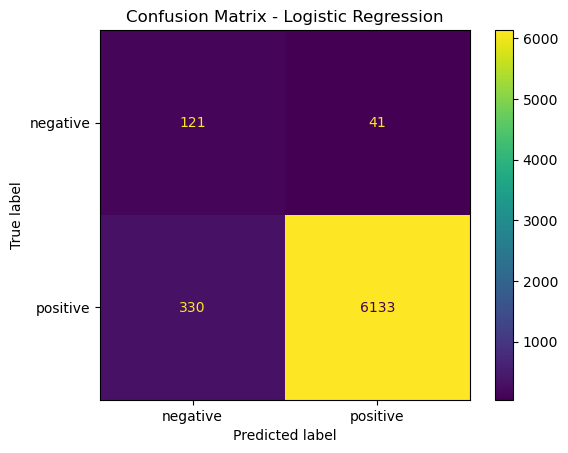

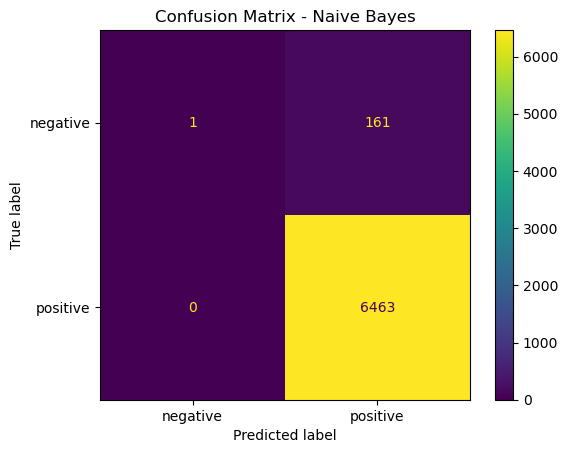

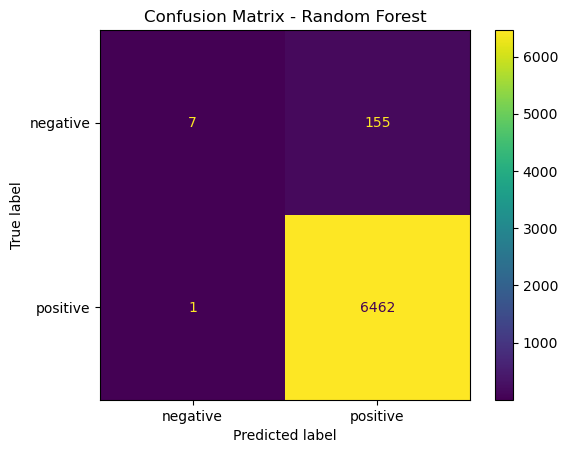

In [41]:
# Display confusion matrix for each model
for model_name, y_pred in model_predictions.items():
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["negative", "positive"]
    )

    disp.plot()
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

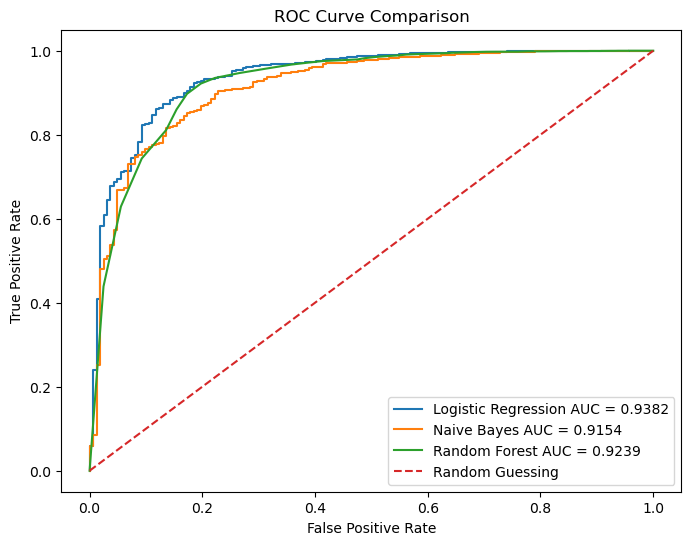

In [42]:
# ROC Curve for models that support probability prediction
plt.figure(figsize=(8, 6))

for model_name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_tfidf)[:, 1]
        fpr, tpr, thresholds = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f"{model_name} AUC = {roc_auc:.4f}")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guessing")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [43]:
# Create model comparison table
evaluation_results = []

for model_name, y_pred in model_predictions.items():
    evaluation_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

comparison_df = pd.DataFrame(evaluation_results)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.944000,0.993359,0.948940,0.970642
1,Naive Bayes,0.975698,0.975694,1.000000,0.987698
2,Random Forest,0.976453,0.976575,0.999845,0.988073


## 10. Model Comparison and Best Model Selection

Although Random Forest and Naive Bayes achieved higher overall accuracy, accuracy is not the best metric for this project because the dataset is highly imbalanced.

The dataset contains many more positive reviews than negative reviews. Because of this, a model can achieve high accuracy by mostly predicting positive sentiment.

For this business problem, identifying negative reviews is very important because negative reviews represent unhappy customers. If the model misses negative reviews, the business may fail to respond to customer problems.

Based on the classification reports and confusion matrices, Logistic Regression is the best model for this project because it identifies the highest number of negative reviews compared to the other models.

In [44]:
# Create a comparison table focused on the negative class
negative_class_results = []

for model_name, y_pred in model_predictions.items():
    negative_class_results.append({
        "Model": model_name,
        "Negative Precision": precision_score(y_test, y_pred, pos_label=0),
        "Negative Recall": recall_score(y_test, y_pred, pos_label=0),
        "Negative F1 Score": f1_score(y_test, y_pred, pos_label=0),
        "Accuracy": accuracy_score(y_test, y_pred)
    })

negative_comparison_df = pd.DataFrame(negative_class_results)

negative_comparison_df

,Model,Negative Precision,Negative Recall,Negative F1 Score,Accuracy
0,Logistic Regression,0.268293,0.746914,0.394780,0.944000
1,Naive Bayes,1.000000,0.006173,0.012270,0.975698
2,Random Forest,0.875000,0.043210,0.082353,0.976453


### Final Model Choice

Logistic Regression was selected as the best model for this project.

Even though Random Forest had the highest overall accuracy, it performed poorly on negative reviews. Naive Bayes also achieved high accuracy but missed almost all negative reviews.

Logistic Regression had lower overall accuracy, but it achieved much better recall for the negative class. This means it was better at identifying unhappy customers.

For a business sentiment analysis system, catching negative reviews is more valuable than simply maximizing overall accuracy.

In [45]:
# Save the best model
best_model_name = "Logistic Regression"
best_model = models[best_model_name]

print(f"Best model selected: {best_model_name}")

Best model selected: Logistic Regression


## 11. Error Analysis

After selecting Logistic Regression as the best model, I will analyze the reviews that the model predicted incorrectly.

Error analysis is important because model metrics only show numbers. By looking at actual incorrect predictions, I can better understand why the model struggled.

This step helps answer:

- Which negative reviews were predicted as positive?
- Which positive reviews were predicted as negative?
- Are the incorrect reviews short, unclear, sarcastic, or mixed?
- What improvements could reduce these errors?

In [49]:
# Create a test results dataframe for error analysis
error_analysis_df = pd.DataFrame({
    "review_text": X_test,
    "actual_label": y_test,
    "predicted_label": model_predictions[best_model_name]
})

# Add readable sentiment labels
error_analysis_df["actual_sentiment"] = error_analysis_df["actual_label"].map({
    0: "negative",
    1: "positive"
})

error_analysis_df["predicted_sentiment"] = error_analysis_df["predicted_label"].map({
    0: "negative",
    1: "positive"
})

# Identify incorrect predictions
incorrect_predictions = error_analysis_df[
    error_analysis_df["actual_label"] != error_analysis_df["predicted_label"]
].copy()

print(f"Total incorrect predictions: {incorrect_predictions.shape[0]}")
incorrect_predictions.head()

Total incorrect predictions: 371


,review_text,actual_label,predicted_label,actual_sentiment,predicted_sentiment
28761,love new kindle thought screen would large usi...,1,0,positive,negative
14797,good device previous one inherited cracked screen,1,0,positive,negative
22010,understand well use turn liights open gargae etc,1,0,positive,negative
2073,amazon wrong device precious,1,0,positive,negative
21915,great purchase way better anticipated wish wou...,1,0,positive,negative


In [50]:
# Negative reviews incorrectly predicted as positive
false_positives_for_business = incorrect_predictions[
    (incorrect_predictions["actual_sentiment"] == "negative") &
    (incorrect_predictions["predicted_sentiment"] == "positive")
]

print(f"Negative reviews predicted as positive: {false_positives_for_business.shape[0]}")

false_positives_for_business[[
    "review_text",
    "actual_sentiment",
    "predicted_sentiment"
]].head(10)

Negative reviews predicted as positive: 41


,review_text,actual_sentiment,predicted_sentiment
26806,nice idea need gadget opinion worth money comp...,negative,positive
3913,item bought gift used device seems year old en...,negative,positive
649,wife wanted ipad bought cheaper good reading p...,negative,positive
13213,satisfied purchase price guess,negative,positive
3906,wish camera quality better,negative,positive
16113,disappointed toddler friendly kindle inside ki...,negative,positive
17572,reading book great working pdf file great also...,negative,positive
14780,protector made fire large direction coherent w...,negative,positive
13722,purchased kid hard navigate ended purchasing ipad,negative,positive
9331,lot apps incomplete run apps great lot apps ge...,negative,positive


In [51]:
# Positive reviews incorrectly predicted as negative
false_negatives_for_business = incorrect_predictions[
    (incorrect_predictions["actual_sentiment"] == "positive") &
    (incorrect_predictions["predicted_sentiment"] == "negative")
]

print(f"Positive reviews predicted as negative: {false_negatives_for_business.shape[0]}")

false_negatives_for_business[[
    "review_text",
    "actual_sentiment",
    "predicted_sentiment"
]].head(10)

Positive reviews predicted as negative: 330


,review_text,actual_sentiment,predicted_sentiment
28761,love new kindle thought screen would large usi...,positive,negative
14797,good device previous one inherited cracked screen,positive,negative
22010,understand well use turn liights open gargae etc,positive,negative
2073,amazon wrong device precious,positive,negative
21915,great purchase way better anticipated wish wou...,positive,negative
5485,purchase tablet black friday classroom work to...,positive,negative
20969,first good news screen nice brightness word cr...,positive,negative
29220,purchased loved sound quality alexa added bonu...,positive,negative
9329,cheap device running amazon problem installing...,positive,negative
5213,fast buck would give perfect star screen seems...,positive,negative


### Error Analysis Observations

Some incorrect predictions may happen because customer reviews are not always clearly positive or negative.

Common reasons for errors include:

- Very short reviews with limited context
- Mixed reviews that contain both positive and negative words
- Reviews where the star rating and text do not fully match
- Words that have different meanings depending on context
- Sarcasm or indirect language

For example, a review might say the product is useful but also mention problems. This can confuse a traditional TF-IDF machine learning model because it does not deeply understand context like a transformer-based model would.

In [52]:
# Print a few incorrect predictions for manual inspection
for index, row in incorrect_predictions.head(5).iterrows():
    print("=" * 80)
    print(f"Actual Sentiment: {row['actual_sentiment']}")
    print(f"Predicted Sentiment: {row['predicted_sentiment']}")
    print("Review Text:")
    print(row["review_text"])

Actual Sentiment: positive
Predicted Sentiment: negative
Review Text:
love new kindle thought screen would large using day good thin got case feel home like new lock screen lock open tablet tiny hard unlock always taking several time swipe right
Actual Sentiment: positive
Predicted Sentiment: negative
Review Text:
good device previous one inherited cracked screen
Actual Sentiment: positive
Predicted Sentiment: negative
Review Text:
understand well use turn liights open gargae etc
Actual Sentiment: positive
Predicted Sentiment: negative
Review Text:
amazon wrong device precious
Actual Sentiment: positive
Predicted Sentiment: negative
Review Text:
great purchase way better anticipated wish would bought one sooner


## 12. Conclusion

In this project, I built a Natural Language Processing machine learning pipeline to classify Amazon customer reviews as positive or negative.

The project included:

- Loading and inspecting a real-world customer review dataset
- Creating sentiment labels from star ratings
- Exploring class imbalance and review length patterns
- Cleaning and preprocessing raw text data
- Converting text into numerical features using TF-IDF
- Training and comparing Logistic Regression, Naive Bayes, and Random Forest models
- Evaluating models using accuracy, precision, recall, F1-score, confusion matrices, and ROC curves
- Performing error analysis on incorrect predictions

The dataset was highly imbalanced, with many more positive reviews than negative reviews. Because of this, accuracy alone was not enough to choose the best model.

Although Naive Bayes and Random Forest achieved higher overall accuracy, they performed poorly on negative reviews. Logistic Regression was selected as the best model because it had much stronger recall for the negative class.

From a business perspective, this is important because negative reviews represent unhappy customers. A sentiment analysis system should help businesses identify customer problems quickly, not just maximize overall accuracy.

### Business Value

This model could help an online business:

- Automatically monitor customer reviews
- Detect unhappy customers faster
- Prioritize negative feedback for customer support teams
- Understand product issues at scale
- Improve customer satisfaction tracking

### Limitations

This project uses traditional machine learning with TF-IDF features. While this approach is effective and interpretable, it does not fully understand deep language context, sarcasm, or complex mixed opinions.

Some errors happened because reviews were short, unclear, mixed, or because the written text did not fully match the star rating.

### Future Improvements

Future improvements could include:

- Testing different TF-IDF settings
- Using SMOTE or other imbalance-handling techniques
- Trying Linear SVM for text classification
- Using transformer models such as BERT
- Building a dashboard to monitor review sentiment
- Deploying the model as a web application or API

In [53]:
# Add original review text using the original index
error_analysis_df["original_review_text"] = sentiment_df.loc[X_test.index, "review_text"]

# Show incorrect predictions with original review text
incorrect_predictions = error_analysis_df[
    error_analysis_df["actual_label"] != error_analysis_df["predicted_label"]
].copy()

incorrect_predictions[[
    "original_review_text",
    "actual_sentiment",
    "predicted_sentiment"
]].head()

,original_review_text,actual_sentiment,predicted_sentiment
28761,"Love my new kindle, thought the screen would b...",positive,negative
14797,Good device. My previous one was inherited and...,positive,negative
22010,"Understand me very well, Use it to turn on lii...",positive,negative
2073,"Oh my, oh my, oh my! Amazon can do no wrong! T...",positive,negative
21915,Such a great purchase! It's way better than I ...,positive,negative


In [54]:
# Print a few incorrect predictions with original review text
for index, row in incorrect_predictions.head(5).iterrows():
    print("=" * 80)
    print(f"Actual Sentiment: {row['actual_sentiment']}")
    print(f"Predicted Sentiment: {row['predicted_sentiment']}")
    print("Original Review Text:")
    print(row["original_review_text"])

Actual Sentiment: positive
Predicted Sentiment: negative
Original Review Text:
Love my new kindle, thought the screen would be too large but after using it a few days, all is good. Very thin , got a case for it, I now feel at home with it. Do not like the "new" lock screen lock to open the tablet at all, its tiny and hard to "unlock" most always taking several times to swipe it just right.
Actual Sentiment: positive
Predicted Sentiment: negative
Original Review Text:
Good device. My previous one was inherited and has a cracked screen.
Actual Sentiment: positive
Predicted Sentiment: negative
Original Review Text:
Understand me very well, Use it to turn on liights, open the gargae , etc.
Actual Sentiment: positive
Predicted Sentiment: negative
Original Review Text:
Oh my, oh my, oh my! Amazon can do no wrong! This device is my precious!
Actual Sentiment: positive
Predicted Sentiment: negative
Original Review Text:
Such a great purchase! It's way better than I had anticipated! Wish I woul